In [331]:
import requests
import pandas as pd
from datetime import datetime, timedelta, timezone


SPOT_URL = "https://api.binance.com/api/v3/klines"
FUTURES_URL = "https://fapi.binance.com/fapi/v1/klines"
FUNDING_URL = "https://fapi.binance.com/fapi/v1/fundingRate"


def _download_klines(url, symbol, interval, start_ms, end_ms):
    r = requests.get(
        url,
        params={
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1000,
        },
        timeout=20,
    )
    r.raise_for_status()

    df = pd.DataFrame(
        r.json(),
        columns=[
            "open_time", "open", "high", "low", "close", "volume",
            "close_time", "quote_volume", "num_trades",
            "taker_base", "taker_quote", "ignore"
        ],
    )

    df["datetime"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close"] = df["close"].astype(float)

    return df[["datetime", "close"]]


def _download_funding(symbol, start_ms, end_ms):
    dfs = []

    current = start_ms

    while current < end_ms:

        r = requests.get(
            FUNDING_URL,
            params={
                "symbol": symbol,
                "startTime": current,
                "endTime": end_ms,
                "limit": 1000,
            },
            timeout=20,
        )

        r.raise_for_status()

        data = r.json()

        if len(data) == 0:
            break

        df = pd.DataFrame(data)

        df["datetime"] = pd.to_datetime(df["fundingTime"], unit="ms", utc=True)
        df["fundingRate"] = df["fundingRate"].astype(float)

        dfs.append(df[["datetime", "fundingRate"]])

        current = int(df["datetime"].iloc[-1].timestamp() * 1000) + 1

    funding = pd.concat(dfs, ignore_index=True)

    return funding


def _get_binance_history(symbol="BTCUSDT", days=365):
    """
    Returns
    -------
    spot_daily : Daily spot close
    futures_daily : Daily perpetual close
    funding_8h : Every funding observation
    funding_daily : Daily realized funding
    """

    end = datetime.now(timezone.utc)
    start = end - timedelta(days=days)

    start_ms = int(start.timestamp() * 1000)
    end_ms = int(end.timestamp() * 1000)

    # Daily closes
    spot_daily = _download_klines(
        SPOT_URL,
        symbol,
        "1d",
        start_ms,
        end_ms,
    )

    futures_daily = _download_klines(
        FUTURES_URL,
        symbol,
        "1d",
        start_ms,
        end_ms,
    )

    # Funding every 8 hours
    funding = _download_funding(
        symbol,
        start_ms,
        end_ms,
    )

    funding_daily = (
        funding
        .assign(date=lambda x: x["datetime"].dt.date)
        .groupby("date", as_index=False)["fundingRate"]
        .sum()
        .rename(columns={"fundingRate": "dailyFunding"})
    )
    spot_daily['date'] = spot_daily.datetime.dt.date
    futures_daily['date'] = futures_daily.datetime.dt.date
    
    return {
        "spot_daily": spot_daily,
        "futures_daily": futures_daily,
        "funding_8h": funding,
        "funding_daily": funding_daily,
    }
    

def get_basis_funding_history(symbol="BTCUSDT", days=365):

    ### Get data
    data = _get_binance_history(symbol=symbol, days=days)
    
    spot = data["spot_daily"]
    futures = data["futures_daily"]
    funding = data["funding_8h"]
    daily_funding = data["funding_daily"]

    ### Combine data
    basis_fr_df = (
        spot.rename(columns={'close':'spot'}).drop(columns='datetime')
        .merge(futures.rename(columns={'close':'futures'}).drop(columns='datetime'), 
               how='left', on='date')
        .merge(daily_funding, 
               how='left', on='date')
    ).set_index('date')
    basis_fr_df['symbol'] = symbol
    
    # Compute daily basis
    basis_fr_df['basis'] = basis_fr_df.futures - basis_fr_df.spot

    rolling_window = 30
    annualization_factor = 365 / rolling_window
    basis_fr_df['geometric_rolling_cum_fr'] = ((1 + basis_fr_df.dailyFunding).rolling(window=rolling_window).apply(np.prod, raw=True) ** annualization_factor - 1)
    basis_fr_df['arithmetic_rolling_cum_fr'] = (basis_fr_df.dailyFunding.rolling(window=rolling_window).sum() * annualization_factor)

    basis_fr_df['spot_ret'] = basis_fr_df.spot.pct_change()
    basis_fr_df['futures_ret'] = basis_fr_df.futures.pct_change()
    basis_fr_df['basis_ret'] = (
        + basis_fr_df['spot_ret'] # long spot
        + (-1) * basis_fr_df['futures_ret'] # short futures
    )

    basis_fr_df['total_ret'] = basis_fr_df['basis_ret'] + basis_fr_df['dailyFunding']
    basis_fr_df['basis_cumret'] = (1 + basis_fr_df['basis_ret']).cumprod()
    basis_fr_df['fr_cumret'] = (1 + basis_fr_df['dailyFunding']).cumprod()
    basis_fr_df['total_cumret'] = basis_fr_df['basis_cumret'] * basis_fr_df['fr_cumret']

    basis_fr_df['spot_cumret'] = (1 + basis_fr_df['spot_ret']).cumprod()
    basis_fr_df['futures_cumret'] = (1 + basis_fr_df['futures_ret']).cumprod()
    basis_fr_df['spot_mdd'] = (basis_fr_df['spot'] / basis_fr_df['spot'].cummax() - 1)
    basis_fr_df['futures_mdd'] = (basis_fr_df['futures'] / basis_fr_df['futures'].cummax() - 1)
    
    return basis_fr_df

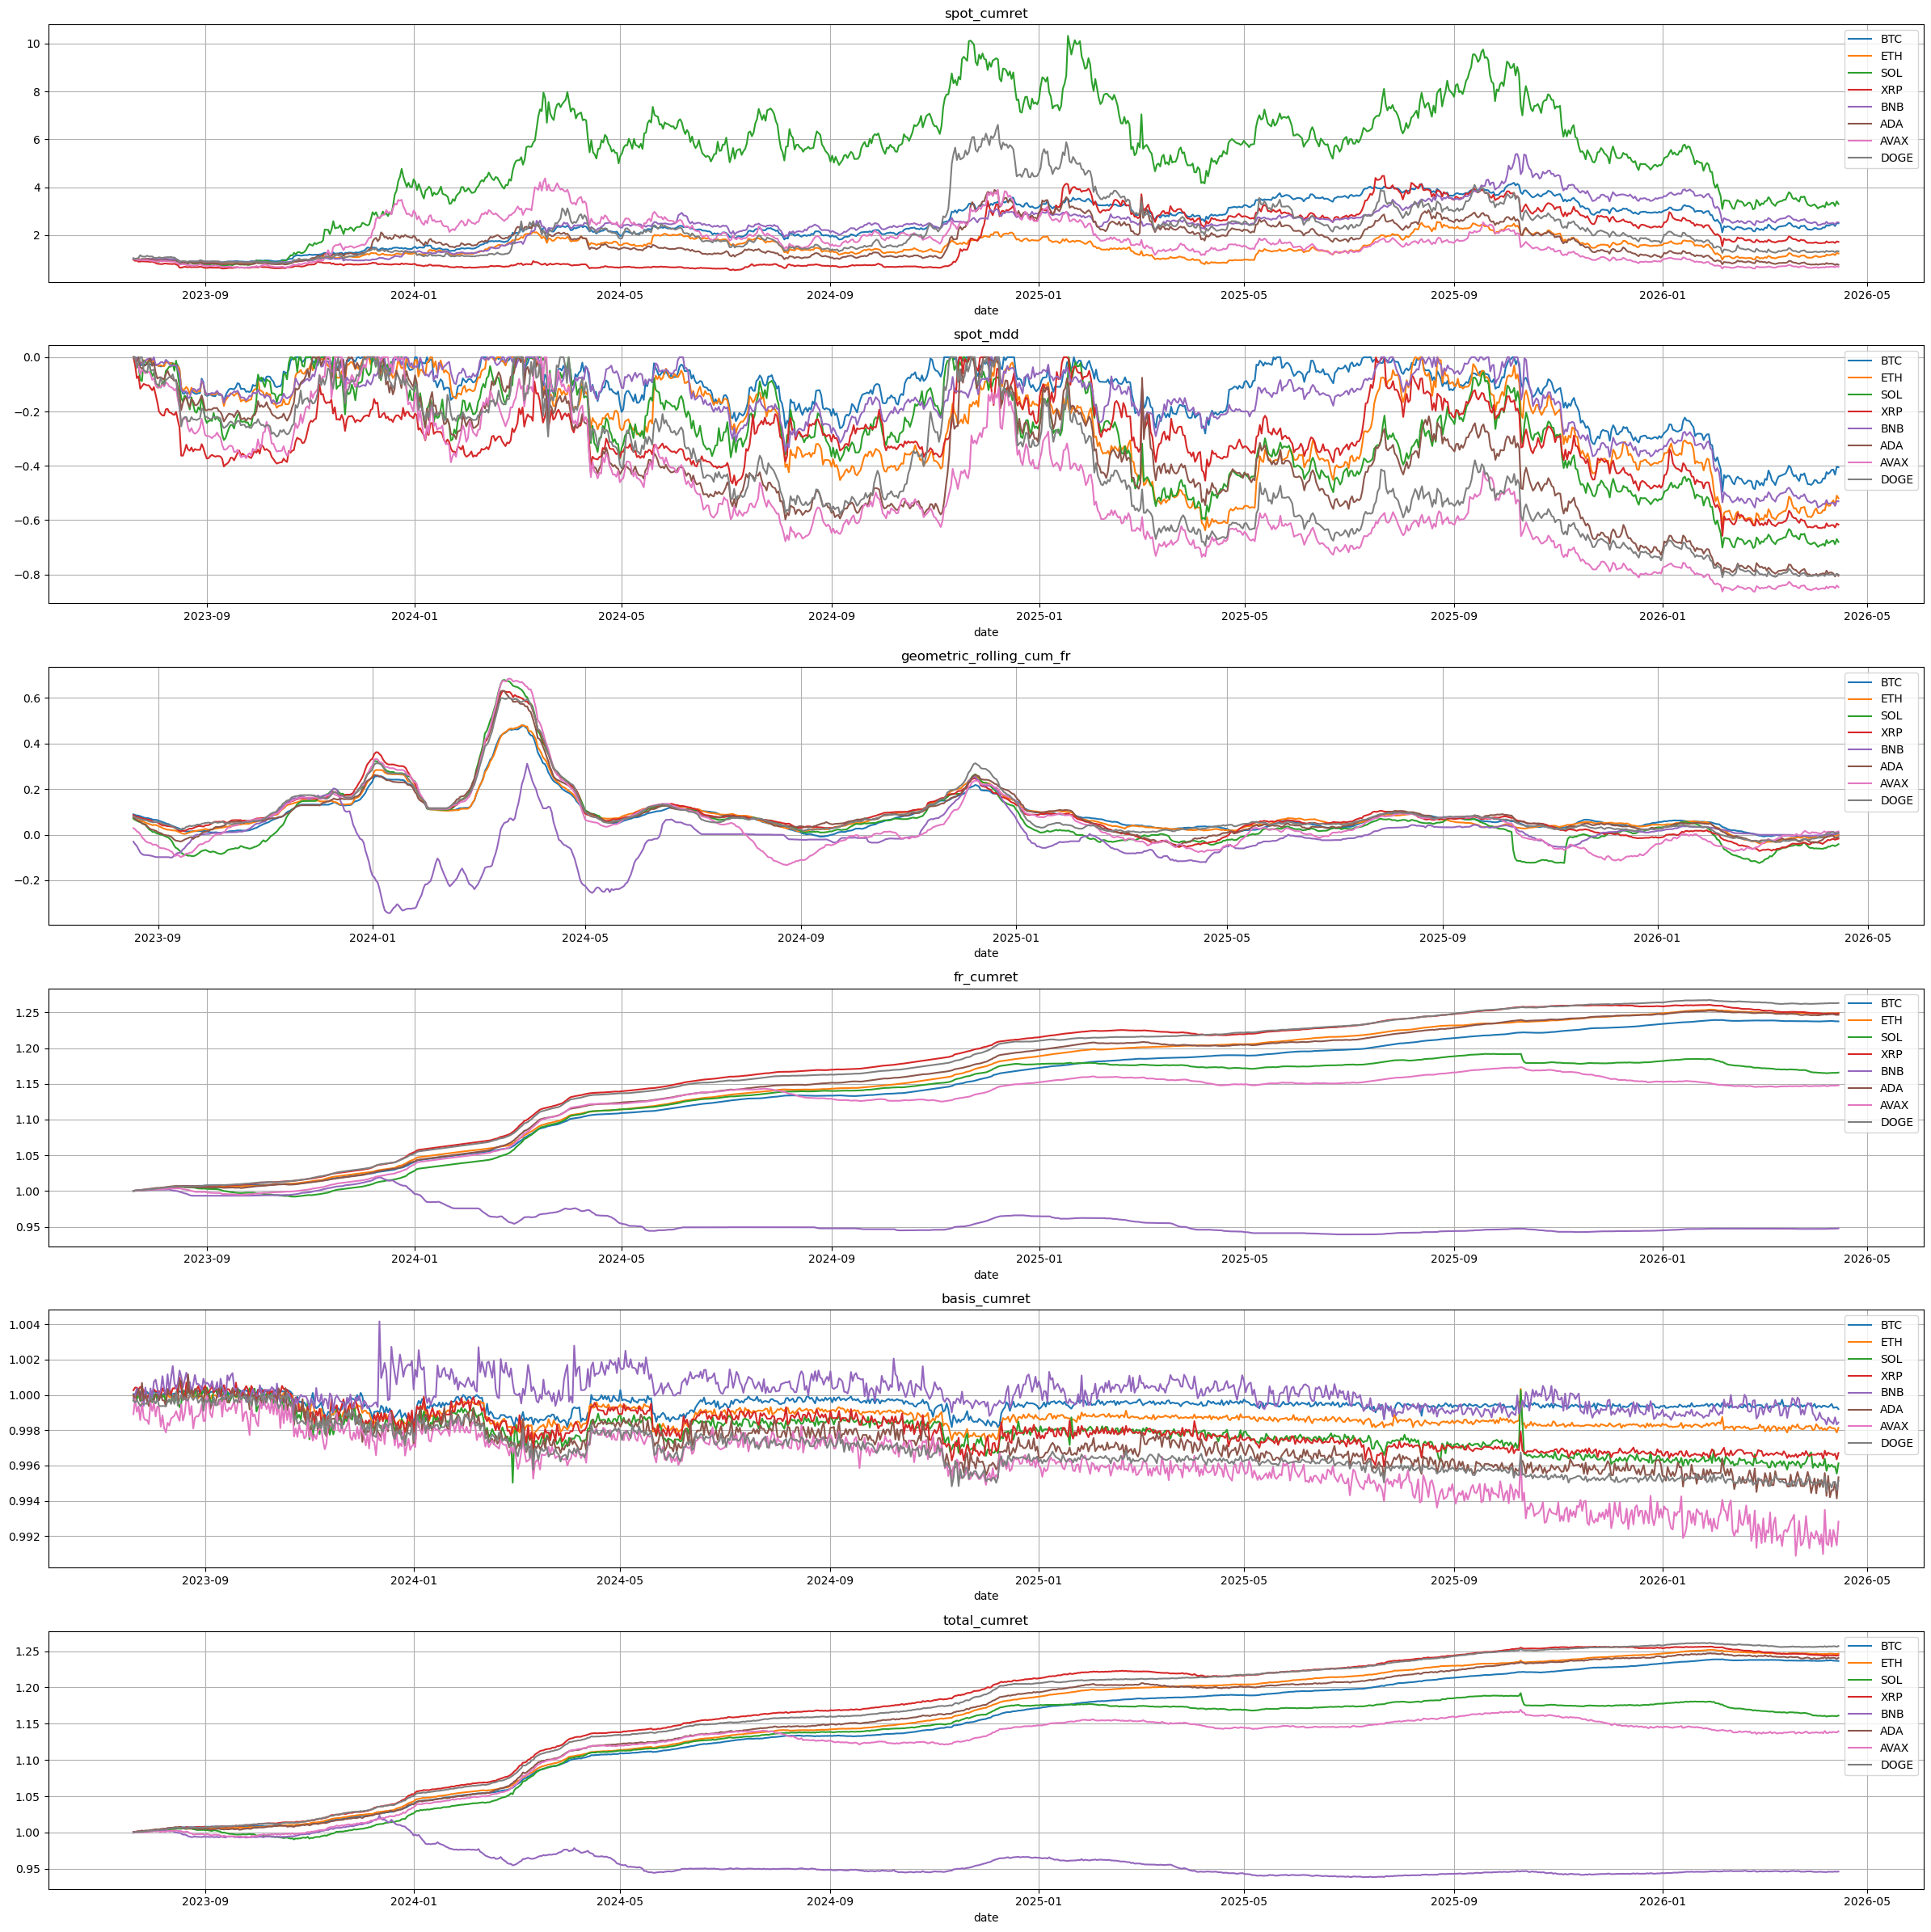

In [352]:
coin_list = ['BTC', 'ETH', 'SOL', 'XRP', 'BNB', 'ADA', 'AVAX', 'DOGE']
dfs = []

fig,ax = plt.subplots(6,1, figsize=(24,24))
for coin in coin_list:
    basis_fr_df = get_basis_funding_history(symbol=f"{coin}USDT", days=365*3)
    dfs.append(basis_fr_df)
    basis_fr_df['spot_cumret'].plot(label=coin, ax=ax[0], title='spot_cumret')
    basis_fr_df['spot_mdd'].plot(label=coin, ax=ax[1], title='spot_mdd')
    basis_fr_df['geometric_rolling_cum_fr'].plot(label=coin, ax=ax[2], title='geometric_rolling_cum_fr')
    basis_fr_df['fr_cumret'].plot(label=coin, ax=ax[3], title='fr_cumret')
    basis_fr_df['basis_cumret'].plot(label=coin, ax=ax[4], title='basis_cumret')
    basis_fr_df['total_cumret'].plot(label=coin, ax=ax[5], title='total_cumret')


for i in range(len(ax)):
    ax[i].grid()
    ax[i].legend()
    #ax[i].axhline(0, c='black')
plt.tight_layout();

comb_basis_fr_df = pd.concat(dfs, axis=0)

In [358]:
comb_basis_fr_df.to_csv('funding_rate_arbitrage.csv')